Import dependencies

In [1]:
# Import necessary libraries
from transformers import pipeline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, f_oneway
from sklearn.cluster import KMeans, OPTICS, DBSCAN, AgglomerativeClustering, SpectralClustering, AffinityPropagation, MeanShift
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF, PCA, LatentDirichletAllocation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.mixture import GaussianMixture
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import statsmodels.api as sm
from sentence_transformers import SentenceTransformer
from scipy import stats
from textblob import TextBlob
from nltk.tokenize import word_tokenize
import nltk
import numpy as np
nltk.download('punkt')

/Users/alexanders/ml-project-2-peaceduke-1/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/alexanders/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

Function definitions

In [31]:
# Define functions for various tasks
def load_data(file_path):
    return pd.read_pickle(file_path)

def save_data(df, file_path):
    df.to_pickle(file_path)

def cluster_features(features, df, n_clusters=3):
    new_df = df.copy()
    for feature in features:
        kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(new_df[[feature]].dropna())
        new_df["Cluster_" + feature] = kmeans.labels_
    return new_df

def perform_anova(new_df, feature, label):
    groups = [new_df[feature][new_df[f'Cluster_{feature}'] == label] for label in new_df[f'Cluster_{feature}'].unique()]
    f_statistic, p_value = stats.f_oneway(*groups)
    alpha = 0.05
    significance = "significantly different" if p_value < alpha else "not significantly different"
    return f_statistic, p_value, significance

def chi_square_test(new_df, feature, dep, alpha=0.05):
    contingency_table = pd.crosstab(new_df[f"Cluster_{feature}"], new_df[dep])
    chi2, p, _, _ = chi2_contingency(contingency_table)
    bonferroni_alpha = alpha / len(pd.unique(new_df[dep]))
    significance = "significant" if p < bonferroni_alpha else "not significant"
    return chi2, p, significance

def find_dominant_clusters(contingency_table, factor=2):
    dominant_clusters = []
    for col in contingency_table.columns:
        values = contingency_table[col]
        sorted_values = values.sort_values(ascending=False)
        if sorted_values.iloc[0] > factor * sorted_values.iloc[1]:
            dominant_clusters.append((col, sorted_values.index[0]))
    return dominant_clusters

def most_vs_least_popular(contingency_table):
    for index, row in contingency_table.iterrows():
        most_popular = row.max()
        least_popular = row.min()
        difference = (most_popular / least_popular - 1) * 100
        print(f"{index}: Most popular type is larger than least popular type by {int(difference)}%")

def bar_plot_clusters(new_df, feature, label):
    plt.figure(figsize=(5, 5))
    sns.boxplot(data=new_df, x=f'Cluster_{feature}', y=feature)
    plt.xlabel('Cluster Labels')
    plt.ylabel(f'{feature} Feature')
    plt.title(label)
    plt.savefig(f'figures/{label}_{feature}.png')
    plt.show()

def top_words(vectorizer, df, n=10):
    vectorized_data = vectorizer.fit_transform(df["Sentences Overall"])
    tfidf_sum = np.sum(vectorized_data, axis=0).A1
    words = vectorizer.get_feature_names_out()
    sorted_indices = np.argsort(tfidf_sum).flatten()[::-1]
    return [words[i] for i in sorted_indices[:n]]

def unique_words_per_cluster(new_df):
    aggregated_df = new_df.groupby('Cluster_Interesting')['Sentences Overall'].apply(' '.join).reset_index()
    cluster_top_words = {}
    for _, row in aggregated_df.iterrows():
        cluster_id = row['Cluster_Interesting']
        sentences = pd.DataFrame({'Sentences Overall': [row['Sentences Overall']]})
        top_words_list = top_words(TfidfVectorizer(stop_words="english"), sentences)
        cluster_top_words[cluster_id] = set(top_words_list)
    for cluster_id, words in cluster_top_words.items():
        other_clusters = set.union(*[words for cid, words in cluster_top_words.items() if cid != cluster_id])
        unique_words = words - other_clusters
        print(f"Cluster {cluster_id}: {unique_words}")

def get_top_n_tfidf_features(corpus, n=50):
    vectorizer = TfidfVectorizer()
    tfid_embedding = vectorizer.fit_transform(corpus).toarray()
    tfidf_sums = tfid_embedding.sum(axis=0)
    top_n_indices = np.sort(np.argsort(tfidf_sums)[-n:])
    return tfid_embedding[:, top_n_indices]

def scale_data(data):
    scaler = StandardScaler()
    return scaler.fit_transform(data)

def plot_clusters(scaled_data, labels, title):
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(scaled_data)
    plt.figure()
    plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap="viridis", edgecolors="k", s=50)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title(title)
    plt.savefig(f'figures/{title}.png')
    plt.show()

def perform_clustering(scaled_data, extra_labels, plot=True):
    clustering_methods = {
        "K-means": KMeans(n_clusters=3, random_state=42),
        "Hierarchical": AgglomerativeClustering(n_clusters=5, linkage="ward"),
        "DBSCAN": DBSCAN(metric="manhattan"),
        "GMM": GaussianMixture(n_components=3, random_state=42),
        "Spectral": SpectralClustering(n_clusters=3, affinity='nearest_neighbors', random_state=42),
        "Affinity Propagation": AffinityPropagation(random_state=42),
        "Mean Shift": MeanShift()
    }
    labels = {name: method.fit_predict(scaled_data) for name, method in clustering_methods.items()}
    if plot:
        for name, lbls in labels.items():
            plot_clusters(scaled_data, lbls, name)
        plot_clusters(scaled_data, LabelEncoder().fit_transform(extra_labels), "Custom Labels")
    return labels

def flatten_embeddings(all_text):
    vectors = all_text["embedding"].to_numpy()
    return np.vstack(vectors)

def print_top_words_per_cluster(vectorizer, corpus, labels, n_clusters, n_top_words=10):
    count_matrix = vectorizer.fit_transform(corpus)
    feature_names = vectorizer.get_feature_names_out()
    for cluster_num in range(n_clusters):
        print(f"Cluster #{cluster_num + 1}:")
        cluster_docs = np.where(labels == cluster_num)[0]
        cluster_matrix = count_matrix[cluster_docs]
        word_counts = np.asarray(cluster_matrix.sum(axis=0)).flatten()
        top_word_indices = word_counts.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_word_indices]
        print(" ".join(top_words))
        print("\n")

def analyze_scene_type_difference(df, dependent_cols, independent_col):
    results = {}
    for col in dependent_cols:
        group_means = df.groupby(independent_col)[col].mean().to_dict()
        results[col] = {'group_means': group_means}
        if col == 'Sentiment':
            contingency_table = pd.crosstab(df[col], df[independent_col])
            chi2, p, dof, ex = stats.chi2_contingency(contingency_table)
            results[col].update({'chi2': chi2, 'p-value': p, 'degrees of freedom': dof, 'expected frequencies': ex})
        else:
            unique_groups = df[independent_col].unique()
            if len(unique_groups) > 2:
                formula = f'{col} ~ C({independent_col})'
                model = ols(formula, data=df).fit()
                anova_table = sm.stats.anova_lm(model, typ=2)
                results[col].update(anova_table.to_dict())
            else:
                group1 = df[df[independent_col] == unique_groups[0]][col]
                group2 = df[df[independent_col] == unique_groups[1]][col]
                t_stat, p_val = stats.ttest_ind(group1, group2)
                results[col].update({'t-statistic': t_stat, 'p-value': p_val})
        if col != 'Sentiment':
            plt.figure(figsize=(10, 6))
            sns.boxplot(x=independent_col, y=col, data=df)
            plt.title(f'Boxplot of {col} by {independent_col}')
            plt.show()
    return results

def find_top_extreme_words(text, top_n=10):
    words = word_tokenize(text)
    word_sentiments = {word: TextBlob(word).sentiment.polarity for word in words}
    sorted_words = sorted(word_sentiments.items(), key=lambda item: item[1])
    most_negative_words = {word: score for word, score in sorted_words[:top_n]}
    most_positive_words = {word: score for word, score in sorted_words[-top_n:]}
    return {'most_positive_words': most_positive_words, 'most_negative_words': most_negative_words}

def nested_model_selection(df, formulas):
    models = [(formula, ols(formula, data=df).fit()) for formula in formulas]
    best_model = None
    best_anova = None
    min_p_value = float('inf')
    for i in range(len(models) - 1):
        anova_results = anova_lm(models[i][1], models[i + 1][1])
        p_value = anova_results['Pr(>F)'][1]
        if p_value < min_p_value:
            min_p_value = p_value
            best_model = models[i + 1]
            best_anova = anova_results
    print("Best Model Formula:", best_model[0])
    print(best_model[1].summary())
    print("\nANOVA Results:\n", best_anova)

def run_regression(df, formula):
    model = ols(formula, data=df).fit()
    print(model.summary())

def preprocess_df(combined_e2):
    df2 = combined_e2.copy()
    # Rename the columns for consistency and to remove spaces
    df2.rename(columns={
        'Enjoy Working': 'Enjoy_Working',
        'Scene Type': 'Scene_Type',
        'Scene Number': 'Scene_Number'
    }, inplace=True)

    # Convert specified columns to categorical
    df2['Dominant_Topic'] = df2['Dominant_Topic'].astype('category')
    df2['Scene_Type'] = df2['Scene_Type'].astype('category')
    df2['Scene_Number'] = df2['Scene_Number'].astype('category')
    return df2

def print_top_words(model, feature_names, n_top_words):
    """
    Print the top words for each topic.
    
    Parameters:
    model (LatentDirichletAllocation): Fitted LDA model.
    feature_names (array): Array of feature names from the vectorizer.
    n_top_words (int): Number of top words to print for each topic.
    """
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic #{topic_idx + 1}:")
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-n_top_words - 1:-1]]))
        print()

def set_dom(data, vectorizer):
    lda = LatentDirichletAllocation(n_components=5, random_state=42)
    
    # Fit the LDA model
    lda.fit(vectorizer.transform(data["Sentences Overall"]))
    
    # Transform the data
    lda_topics = lda.transform(vectorizer.transform(data["Sentences Overall"]))
    
    # Assign dominant topic
    data["Dominant_Topic"] = np.argmax(lda_topics, axis=1) + 1
    
    # Print top words for each topic
    feature_names = vectorizer.get_feature_names_out()
    print_top_words(lda, feature_names, 10)

def get_top_n_tfidf_features(corpus, n=50):
    """
    Transforms the given corpus into TF-IDF embeddings and returns the top n features by TF-IDF score.

    Parameters:
    corpus (list of str): The corpus of documents to transform.
    n (int): The number of top features to keep.

    Returns:
    np.ndarray: The TF-IDF embedding matrix with only the top n features.
    """
    vectorizer = TfidfVectorizer()
    tfid_embedding = vectorizer.fit_transform(corpus)
    tfid_embedding = tfid_embedding.toarray()
    
    # Sum up the TF-IDF values for each word
    tfidf_sums = tfid_embedding.sum(axis=0)
    
    # Get the indices of the top n words
    top_n_indices = np.argsort(tfidf_sums)[-n:]
    
    # Sort the indices to keep the columns in the same order
    top_n_indices = np.sort(top_n_indices)
    
    # Keep only the columns corresponding to the top n words
    top_n_tfidf_embedding = tfid_embedding[:, top_n_indices]
    
    return top_n_tfidf_embedding

def scale(data):
    """Applies scaling to data"""
    scaler = StandardScaler()
    s = scaler.fit_transform(data)
    return s

def plot_clusters(scaled_data, labels, title):
    """Projects clusters into 2D for visualization"""
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(scaled_data)

    plt.figure()
    plt.scatter(
        pca_result[:, 0],
        pca_result[:, 1],
        c=labels,
        cmap="viridis",
        edgecolors="k",
        s=50,
    )
    plt.xlabel('Principal Component 1')  # Label for x-axis
    plt.ylabel('Principal Component 2')  # Label for y-axis
    plt.title(title)
    plt.savefig(f'figures/{title}.png')
    plt.show()

def to_dict(clusters):
    d = {}
    for e in clusters:
        if e in d: d[e] +=1
        else: d[e] = 1
    tot = sum(d.values())
    for e in d:
        d[e] = d[e] / tot * 100
    print(d)

def reduce_dimension_with_lda(corpus, vectorizer, n_topics=50):
    """
    Reduces the dimensionality of the given corpus using LDA on the TF-IDF matrix.

    Parameters:
    corpus (list of str): The corpus of documents to transform.
    n_topics (int): The number of topics to reduce to.

    Returns:
    np.ndarray: The LDA embedding matrix with the given number of topics.
    """
    # Step 1: Transform the corpus into a TF-IDF matrix
    tfid_embedding = vectorizer.fit_transform(corpus)
    
    # Step 2: Fit the LDA model on the TF-IDF matrix
    lda = LatentDirichletAllocation(n_components=n_topics, random_state=0)
    lda_embedding = lda.fit_transform(tfid_embedding)
    
    return lda_embedding

def vectorize_with_lda(corpus, n_topics=10):
    """
    Vectorizes the given corpus using LDA and returns the topic distribution matrix.

    Parameters:
    corpus (list of str): The corpus of documents to vectorize.
    n_topics (int): The number of topics to extract.

    Returns:
    np.ndarray: The LDA topic distribution matrix for the corpus.
    LatentDirichletAllocation: The fitted LDA model.
    CountVectorizer: The fitted CountVectorizer.
    """
    # Step 1: Convert the corpus into a document-term matrix
    vectorizer = CountVectorizer()
    doc_term_matrix = vectorizer.fit_transform(corpus)
    
    # Step 2: Fit the LDA model on the document-term matrix
    lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
    lda_topic_matrix = lda.fit_transform(doc_term_matrix)
    
    return lda_topic_matrix, lda, vectorizer

def get_top_n_tfidf_features(corpus, vectorizer, n=50):
    """
    Transforms the given corpus into TF-IDF embeddings and returns the top n features by TF-IDF score.

    Parameters:
    corpus (list of str): The corpus of documents to transform.
    n (int): The number of top features to keep.

    Returns:
    np.ndarray: The TF-IDF embedding matrix with only the top n features.
    """
    tfid_embedding = vectorizer.fit_transform(corpus)
    tfid_embedding = tfid_embedding.toarray()
    
    # Sum up the TF-IDF values for each word
    tfidf_sums = tfid_embedding.sum(axis=0)
    
    # Get the indices of the top n words
    top_n_indices = np.argsort(tfidf_sums)[-n:]
    
    # Sort the indices to keep the columns in the same order
    top_n_indices = np.sort(top_n_indices)
    
    # Keep only the columns corresponding to the top n words
    top_n_tfidf_embedding = tfid_embedding[:, top_n_indices]
    
    return top_n_tfidf_embedding

Top word and extreme word extraction

In [26]:
# Load data
combined_e1 = load_data('./text/combined_e1_rob.pkl')
combined_e2 = load_data('./text/combined_e2_rob.pkl')
tfidf_vectorizer = TfidfVectorizer(stop_words="english")

aggregated_type_e1 = combined_e1.groupby('Scene Type')['Sentences Overall'].apply(' '.join).reset_index()
aggregated_type_e2 = combined_e2.groupby('Scene Type')['Sentences Overall'].apply(' '.join).reset_index()

top_image = top_words(tfidf_vectorizer, aggregated_type_e1[aggregated_type_e1['Scene Type'] == 'Image'])
top_video = top_words(tfidf_vectorizer, aggregated_type_e1[aggregated_type_e1['Scene Type'] == 'Video'])
print(f"Common words from image class: {top_image}")
print(f"Common words from video class: {top_video}")

# Find top extreme words
extreme_words_clear_e2 = find_top_extreme_words(aggregated_type_e2[aggregated_type_e2['Scene Type'] == 'Clear']['Sentences Overall'].values[0], top_n=50)
extreme_words_overcast_e2 = find_top_extreme_words(aggregated_type_e2[aggregated_type_e2['Scene Type'] == 'Overcast']['Sentences Overall'].values[0], top_n=50)
print("Unique positive words in Clear:", {word: score for word, score in extreme_words_clear_e2['most_positive_words'].items() if word not in extreme_words_overcast_e2['most_positive_words']})
print("Unique positive words in Overcast:", {word: score for word, score in extreme_words_overcast_e2['most_positive_words'].items() if word not in extreme_words_clear_e2['most_positive_words']})
print("Unique negative words in Clear:", {word: score for word, score in extreme_words_clear_e2['most_negative_words'].items() if word not in extreme_words_overcast_e2['most_negative_words']})
print("Unique negative words in Overcast:", {word: score for word, score in extreme_words_overcast_e2['most_negative_words'].items() if word not in extreme_words_clear_e2['most_negative_words']})


Common words from image class: ['like', 'nice', 'view', 'buildings', 'lot', 'trees', 'building', 'mountains', 'quite', 'people']
Common words from video class: ['like', 'nice', 'view', 'buildings', 'lot', 'trees', 'people', 'building', 'grey', 'interesting']
Unique positive words in Clear: {'cool': 0.35, 'clean': 0.3666666666666667, 'secure': 0.4, 'strong': 0.4333333333333333, 'appropriate': 0.5, 'fitting': 0.5, 'energetic': 0.5, 'surprising': 0.7, 'best': 1.0}
Unique positive words in Overcast: {'comfortably': 0.4, 'sure': 0.5, 'satisfying': 0.5, 'creative': 0.5, 'inspiring': 0.5, 'stunning': 0.5, 'favorite': 0.5, 'own': 0.6, 'greatest': 1.0}
Unique negative words in Clear: {'awful': -1.0, 'frustrated': -0.7, 'blind': -0.5, 'annoyed': -0.4, 'secret': -0.4, 'complex': -0.3, 'lazy': -0.25, 'pale': -0.21, 'tight': -0.17857142857142858, 'typical': -0.16666666666666666, 'average': -0.15, 'active': -0.13333333333333333, 'other': -0.125, 'wide': -0.1, 'empty': -0.1, 'closed': -0.1, 'pity': -

Differences among scene number and scene type by ratings. Anova test for differences between group means

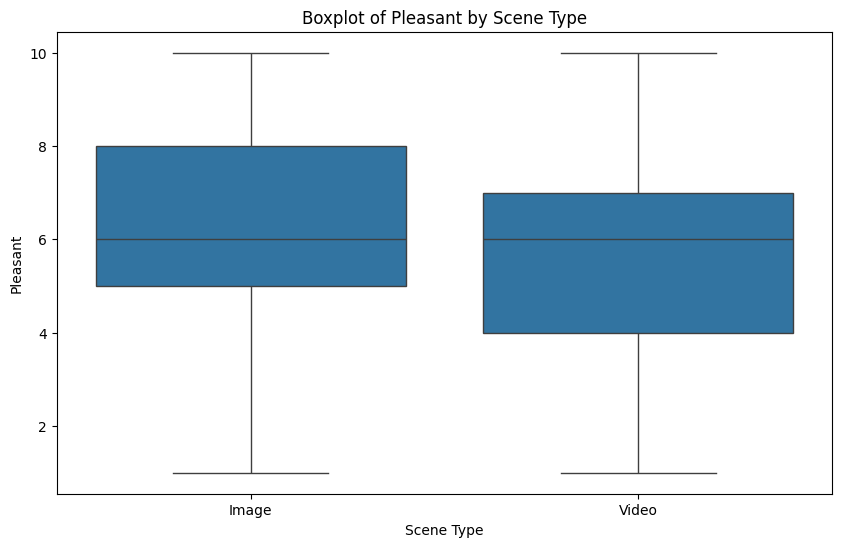

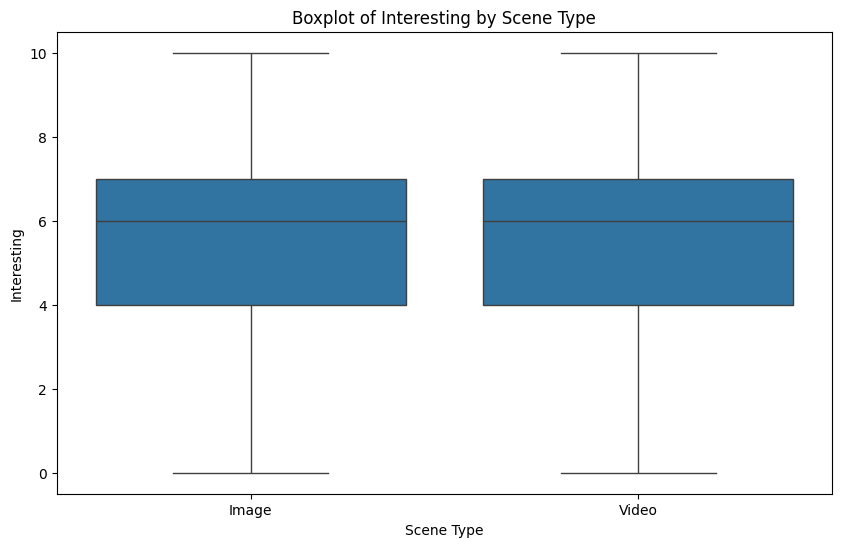

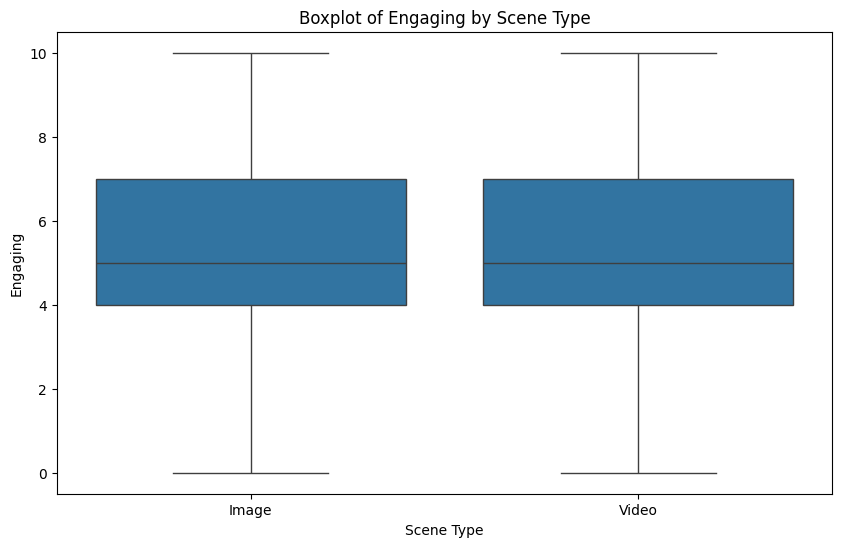

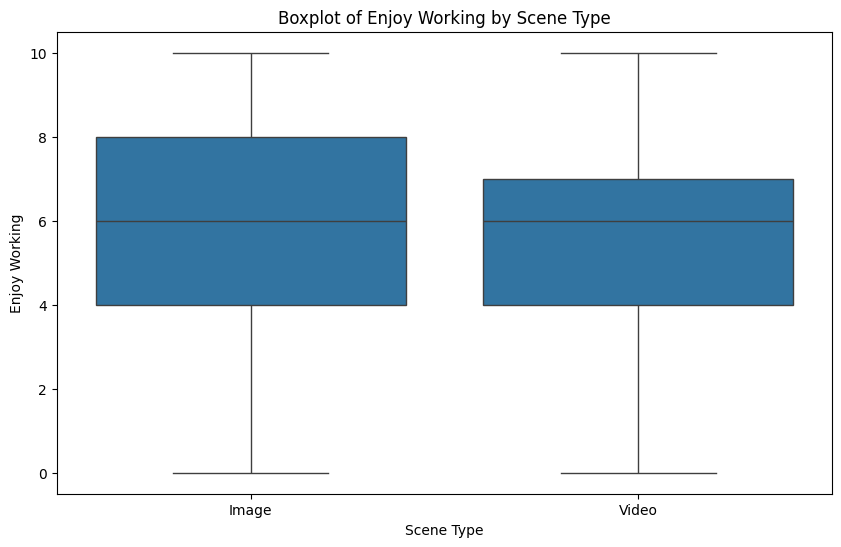

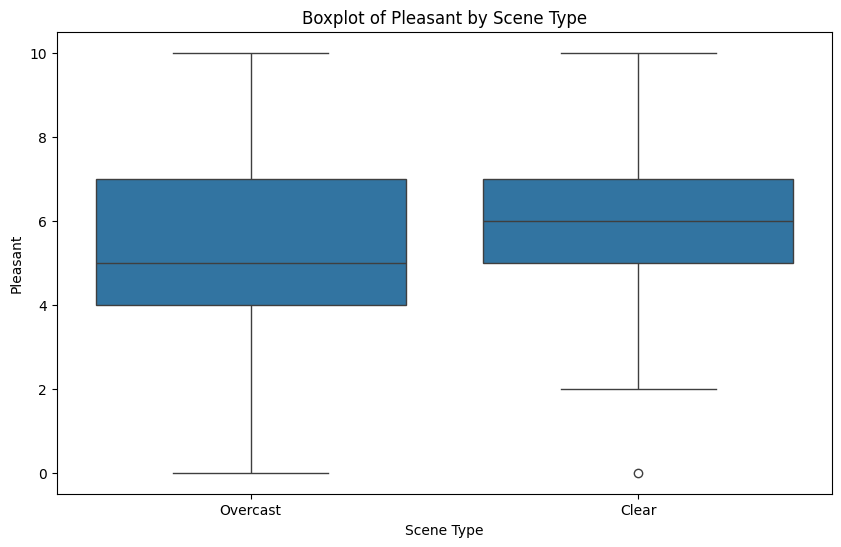

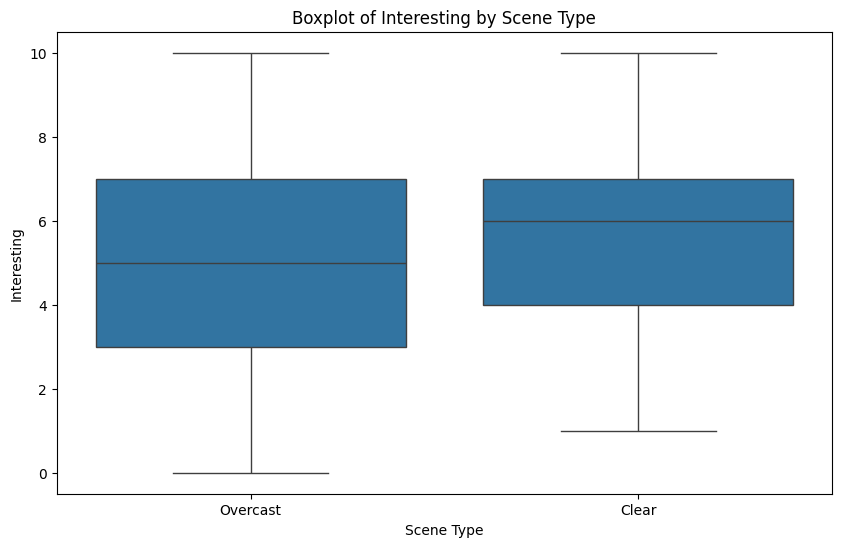

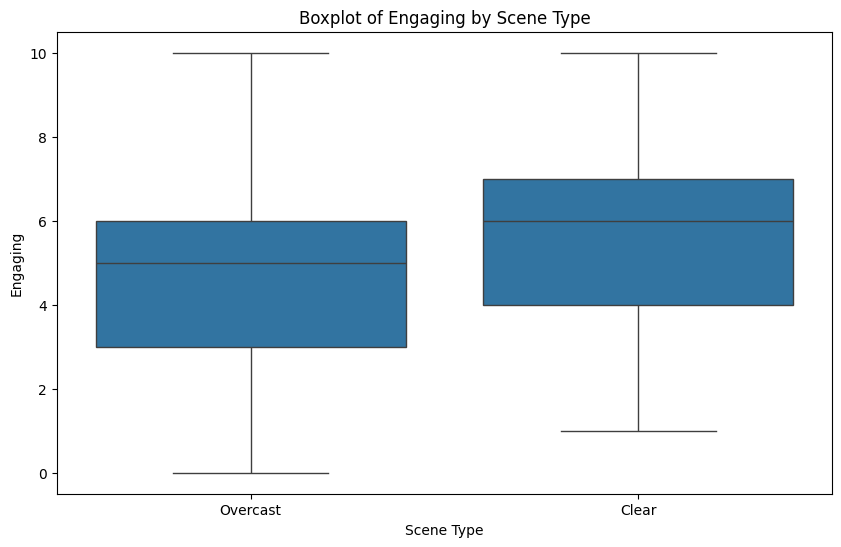

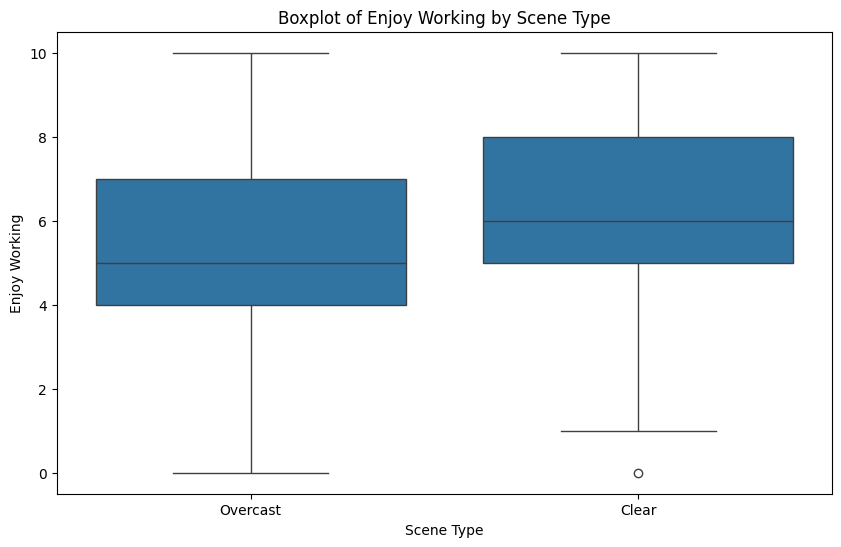

Experiment 1 Scene Type Differences: {'Pleasant': {'group_means': {'Image': 6.042879019908116, 'Video': 5.77760736196319}, 't-statistic': 2.3322468645973595, 'p-value': 0.019839390970327685}, 'Interesting': {'group_means': {'Image': 5.511485451761103, 'Video': 5.441717791411043}, 't-statistic': 0.5883359573953844, 'p-value': 0.5564087753360452}, 'Engaging': {'group_means': {'Image': 5.277182235834609, 'Video': 5.216257668711656}, 't-statistic': 0.5117396843419832, 'p-value': 0.6089199212596488}, 'Enjoy Working': {'group_means': {'Image': 5.865237366003063, 'Video': 5.549079754601227}, 't-statistic': 2.432435164482349, 'p-value': 0.01513157089120726}, 'Sentiment': {'group_means': {'Image': 0.23736600306278713, 'Video': 0.15644171779141106}, 'chi2': 2.057539994478998, 'p-value': 0.15145450563637686, 'degrees of freedom': 1, 'expected frequencies': array([[262.20076628, 261.79923372],
       [390.79923372, 390.20076628]])}}
Experiment 2 Scene Type Differences: {'Pleasant': {'group_means':

In [28]:
# Analyze scene type differences
dependent_columns = ['Pleasant', 'Interesting', 'Engaging', 'Enjoy Working', 'Sentiment']
results_e1 = analyze_scene_type_difference(combined_e1, dependent_columns, 'Scene Type')
results_e2 = analyze_scene_type_difference(combined_e2, dependent_columns, 'Scene Type')
print("Experiment 1 Scene Type Differences:", results_e1)
print("Experiment 2 Scene Type Differences:", results_e2)

Differences in the scene type and scene number frequency among the feature-based clusters

/Users/alexanders/ml-project-2-peaceduke-1/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/alexanders/ml-project-2-peaceduke-1/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/alexanders/ml-project-2-peaceduke-1/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/alexanders/ml-project-2-peaceduke-1/.venv/lib/python3.9/site-packa

Experiment 1 ANOVA: (3738.1883800319406, 0.0, 'significantly different')
Experiment 2 ANOVA: (2287.3845917116946, 0.0, 'significantly different')
Experiment 1 Chi-square: (350.36914384176197, 2.1025553909927636e-57, 'significant')
Experiment 2 Chi-square: (203.92208110321428, 1.6441374522142804e-33, 'significant')
Experiment 1 Dominant Clusters: [(6, 1), (7, 1), (13, 0)]
Experiment 2 Dominant Clusters: [(6, 0), (11, 1), (14, 1)]
0: Most popular type is larger than least popular type by 650%
1: Most popular type is larger than least popular type by 480%
2: Most popular type is larger than least popular type by 171%


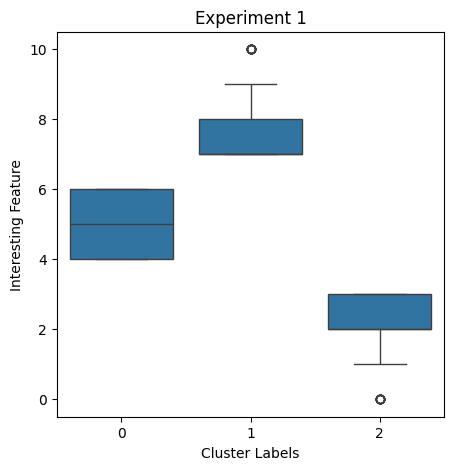

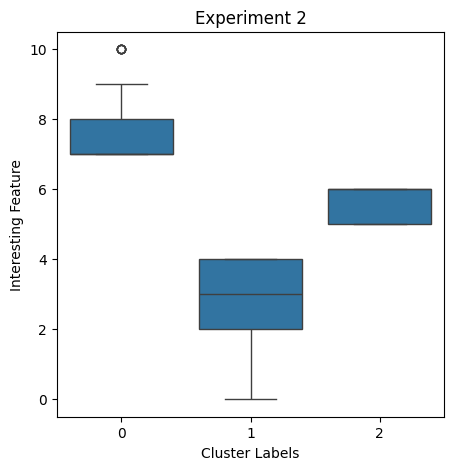

Experiment 1 Unique Words per Cluster:
Cluster 0: {'quite'}
Cluster 1: {'interesting', 'really', 'mountains'}
Cluster 2: {'don', 'feels'}
Experiment 2 Unique Words per Cluster:
Cluster 0: {'open', 'really', 'mountains'}
Cluster 1: {'don', 'grey'}
Cluster 2: {'right'}


In [15]:
# Clustering and ANOVA
features = ["Interesting", "Pleasant", "Engaging", "Enjoy Working"]
new_df_1 = cluster_features(features, combined_e1)
new_df_2 = cluster_features(features, combined_e2)

# Perform ANOVA
anova_results_1 = perform_anova(new_df_1, "Interesting", "Experiment 1")
anova_results_2 = perform_anova(new_df_2, "Interesting", "Experiment 2")
print("Experiment 1 ANOVA:", anova_results_1)
print("Experiment 2 ANOVA:", anova_results_2)

# Chi-square test
chi_square_results_1 = chi_square_test(new_df_1, "Interesting", "Scene Number")
chi_square_results_2 = chi_square_test(new_df_2, "Interesting", "Scene Number")
print("Experiment 1 Chi-square:", chi_square_results_1)
print("Experiment 2 Chi-square:", chi_square_results_2)

# Dominant clusters
contingency_table_1 = pd.crosstab(new_df_1["Cluster_Interesting"], new_df_1["Scene Number"])
contingency_table_2 = pd.crosstab(new_df_2["Cluster_Interesting"], new_df_2["Scene Number"])
dominant_clusters_1 = find_dominant_clusters(contingency_table_1)
dominant_clusters_2 = find_dominant_clusters(contingency_table_2)
print("Experiment 1 Dominant Clusters:", dominant_clusters_1)
print("Experiment 2 Dominant Clusters:", dominant_clusters_2)

# Most vs Least Popular
most_vs_least_popular(contingency_table_2)

# Bar plot for clusters
bar_plot_clusters(new_df_1, 'Interesting', 'Experiment 1')
bar_plot_clusters(new_df_2, 'Interesting', 'Experiment 2')

# Unique words per cluster
print("Experiment 1 Unique Words per Cluster:")
unique_words_per_cluster(new_df_1)
print("Experiment 2 Unique Words per Cluster:")
unique_words_per_cluster(new_df_2)

Sentiment prediction with ordinary least squares linear regression

In [23]:
print("Experiment 1\n")
set_dom(combined_e1, tfidf_vectorizer)
print("Experiment 2\n")
set_dom(combined_e2, tfidf_vectorizer)

# Nested model selection
df1 = preprocess_df(combined_e1)
df2 = preprocess_df(combined_e2)

formulas = [
    'Sentiment ~ Pleasant',
    'Sentiment ~ Pleasant + Enjoy_Working',
    'Sentiment ~ Pleasant + Enjoy_Working + Interesting',
    'Sentiment ~ Pleasant + Enjoy_Working + Dominant_Topic',
    'Sentiment ~ Pleasant + Enjoy_Working + Engaging',
    'Sentiment ~ Pleasant + Enjoy_Working + Engaging + Dominant_Topic'
]
nested_model_selection(df1, formulas)

# Run regression and print summary
run_regression(df1, 'Sentiment ~ C(Scene_Type) + C(Scene_Number) + C(Dominant_Topic)')
run_regression(df2, 'Sentiment ~ C(Scene_Type) + C(Scene_Number) + C(Dominant_Topic)')
run_regression(df2, 'Sentiment ~ C(Scene_Type) + C(Scene_Number)')

Experiment 1

Topic #1:
the and is it like of with but there are

Topic #2:
parts patches suburban composition park symmetrical divides should then predominant

Topic #3:
wrong placed visible aesthetically distribution deep portion artistic pedestrian coolest

Topic #4:
and is it not the to but there of be

Topic #5:
deep portion coolest lawn shade monotonous cozy loud field farther

Experiment 2

Topic #1:
the and is it like but of there with view

Topic #2:
energetic clean spring escape types ruining portion besides curves chaotic

Topic #3:
energetic clean spring escape types ruining portion besides curves chaotic

Topic #4:
soothing energetic clean spring escape types ruining portion besides curves

Topic #5:
energetic clean spring escape types ruining portion besides curves chaotic

Best Model Formula: Sentiment ~ Pleasant + Enjoy_Working
                            OLS Regression Results                            
Dep. Variable:              Sentiment   R-squared:               

Text vectorization based clustering

/Users/alexanders/ml-project-2-peaceduke-1/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


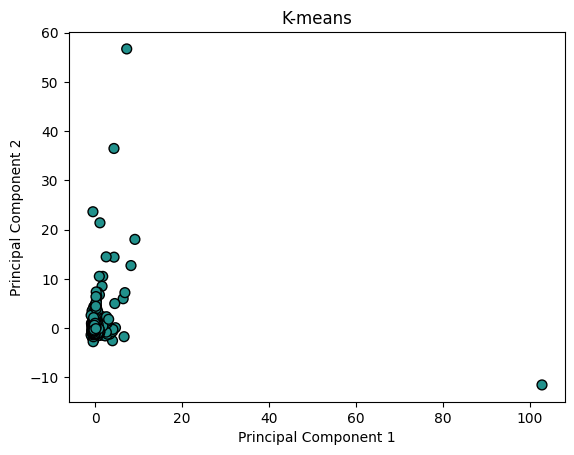

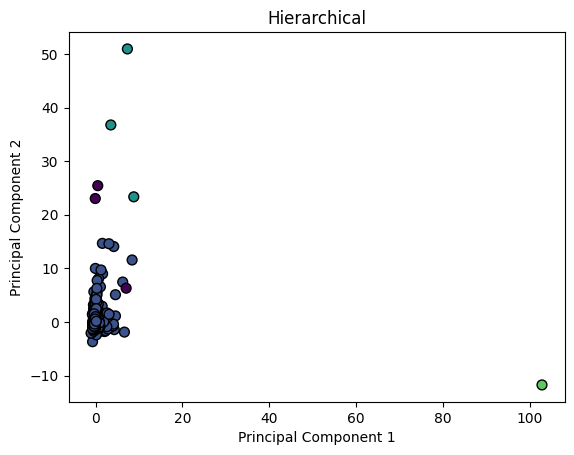

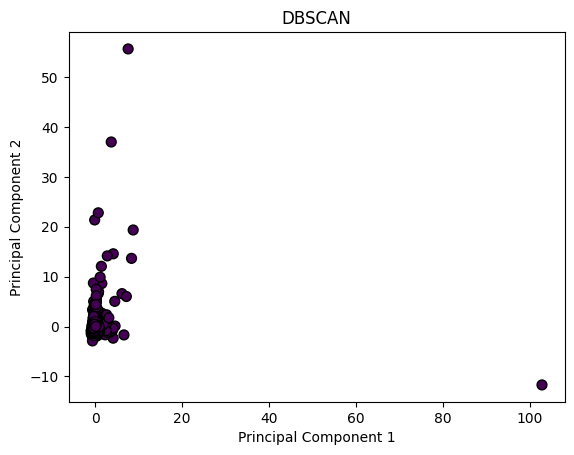

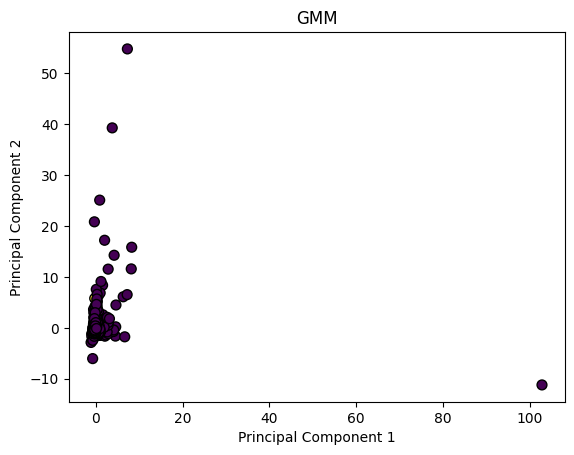

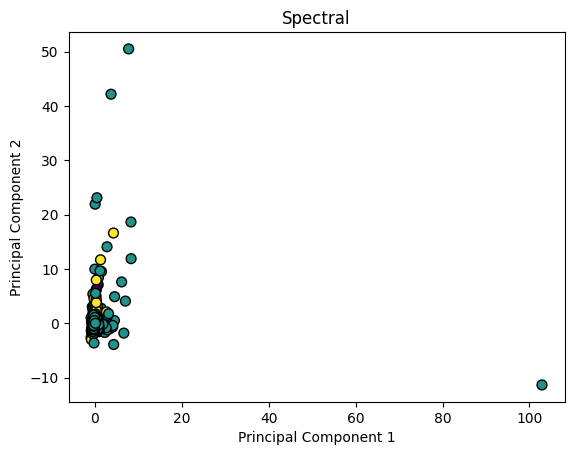

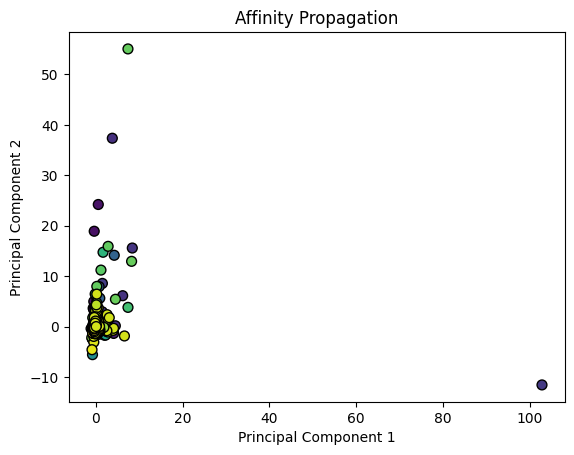

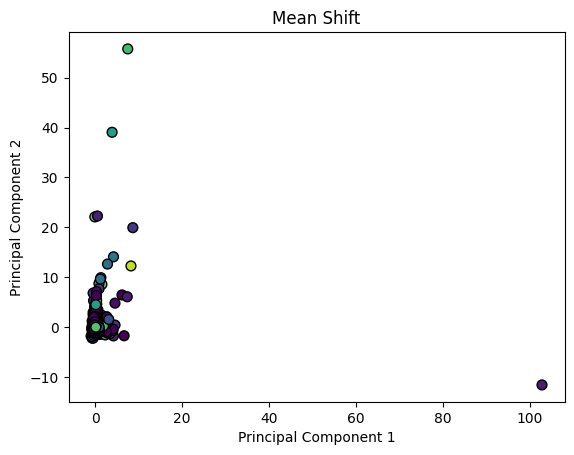

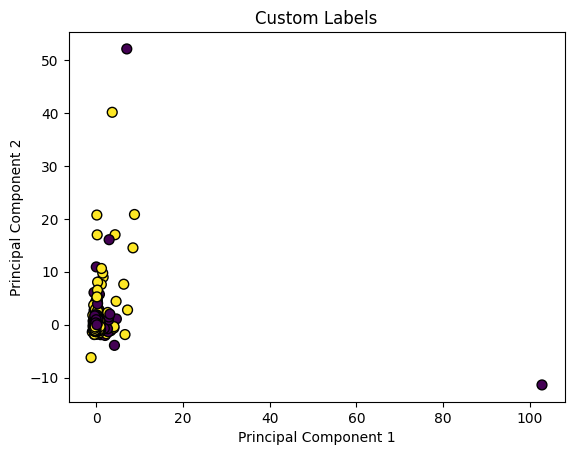

/Users/alexanders/ml-project-2-peaceduke-1/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


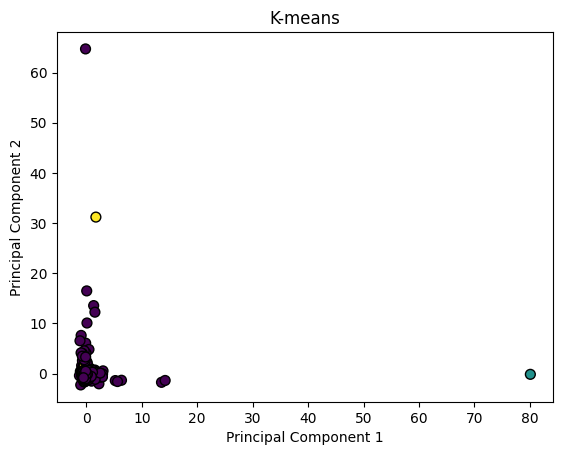

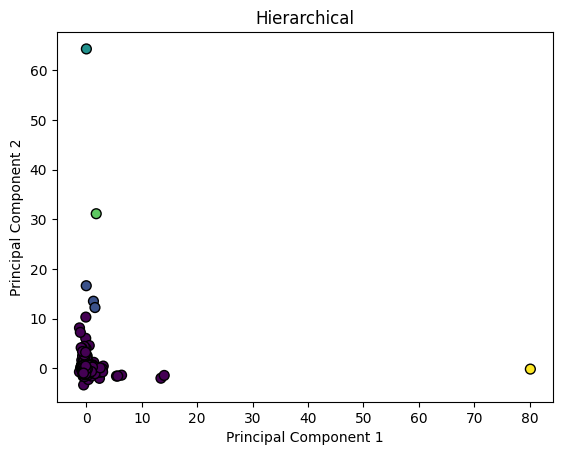

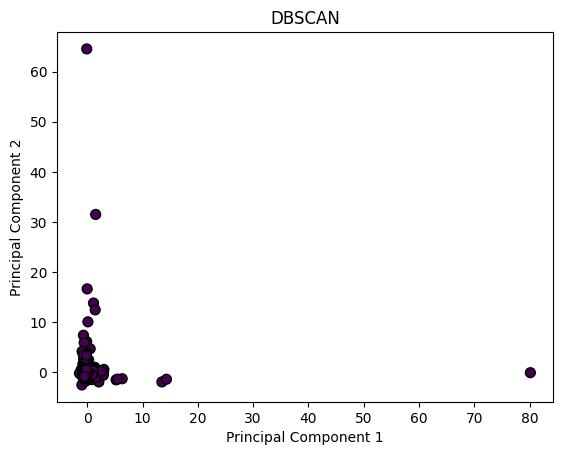

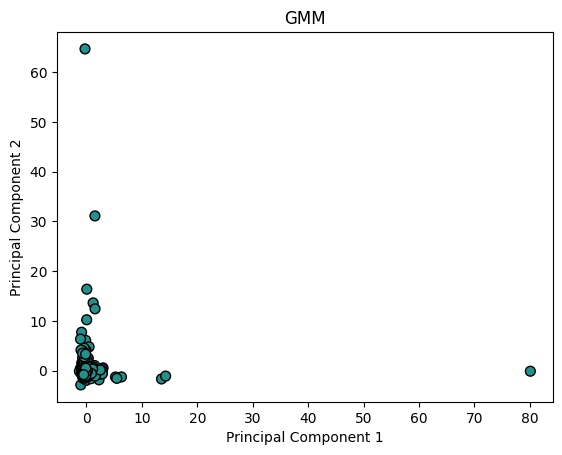

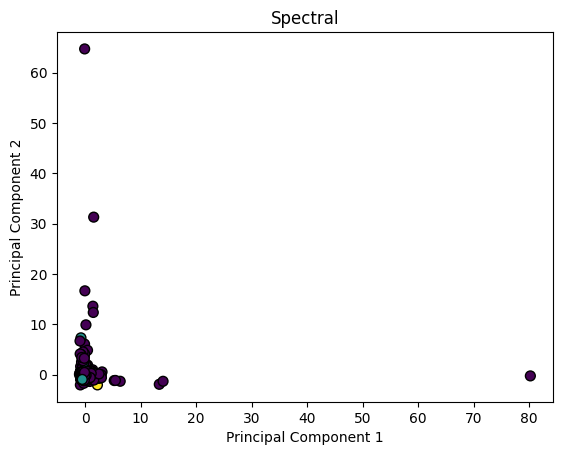

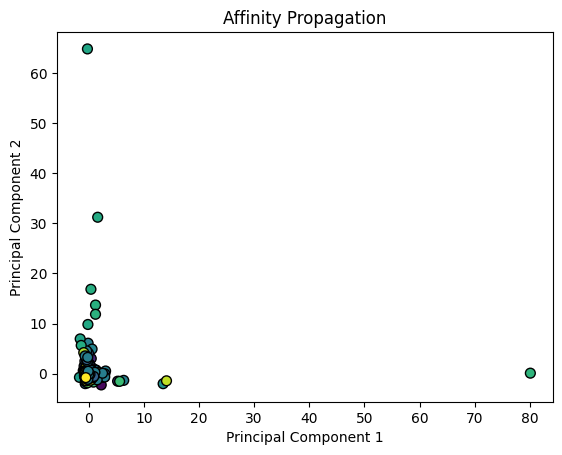

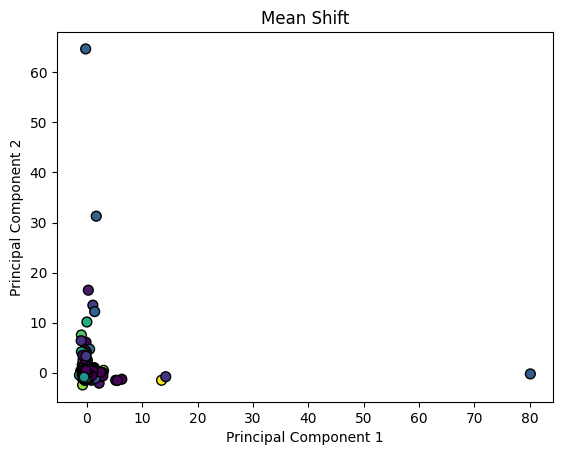

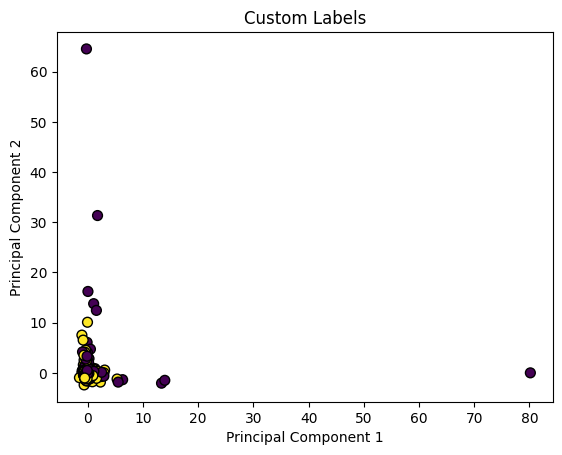

Experiment 1 Top Words per Cluster:
Cluster #1:
really cars stress safe view little don like passing lot


Cluster #2:
like nice view buildings lot trees building people mountains grey


Cluster #3:
grey view flowers sad like colors row weather buildings lot


Experiment 2 Top Words per Cluster:
Cluster #1:
like view nice buildings trees lot feels feel building mountains


Cluster #2:
working library lunch seeing outdoor time supposed nice mood break


Cluster #3:
like trees nice buildings view people lot birds right pass




In [27]:
# Vectorize and scale data
count_vectorizer = CountVectorizer(stop_words="english")
count_e1 = count_vectorizer.fit_transform(combined_e1["Sentences Overall"].values).toarray()
count_e2 = count_vectorizer.fit_transform(combined_e2["Sentences Overall"].values).toarray()

# Perform clustering
scaled_count_e1 = scale_data(count_e1)
labels_e1 = perform_clustering(scaled_count_e1, combined_e1["Scene Type"].values)
scaled_count_e2 = scale_data(count_e2)
labels_e2 = perform_clustering(scaled_count_e2, combined_e2["Scene Type"].values)

# Print top words for each cluster
print("Experiment 1 Top Words per Cluster:")
print_top_words_per_cluster(count_vectorizer, combined_e1["Sentences Overall"].values, labels_e1["K-means"], n_clusters=3)
print("Experiment 2 Top Words per Cluster:")
print_top_words_per_cluster(count_vectorizer, combined_e2["Sentences Overall"].values, labels_e2["K-means"], n_clusters=3)


/Users/alexanders/ml-project-2-peaceduke-1/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/alexanders/ml-project-2-peaceduke-1/.venv/lib/python3.9/site-packages/sklearn/cluster/_affinity_propagation.py:142: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(


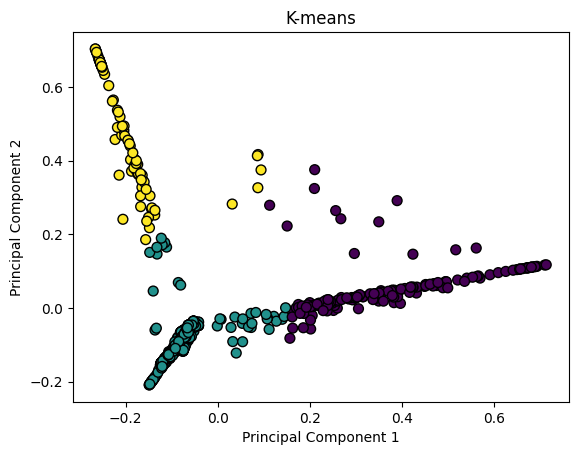

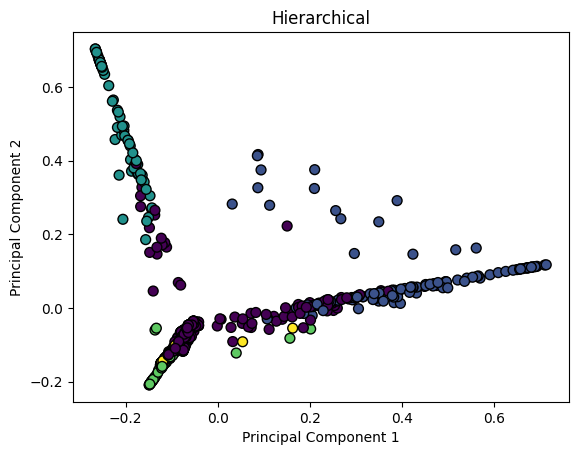

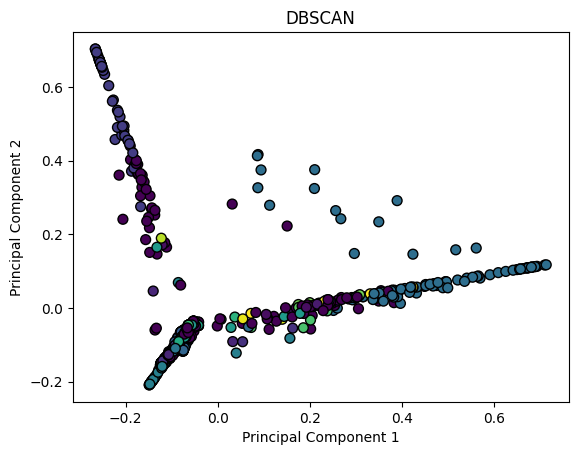

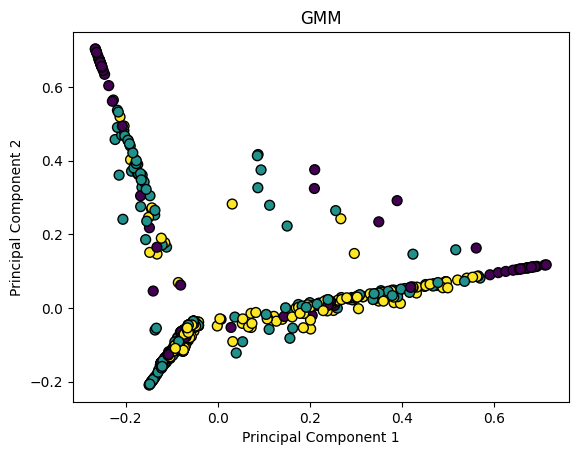

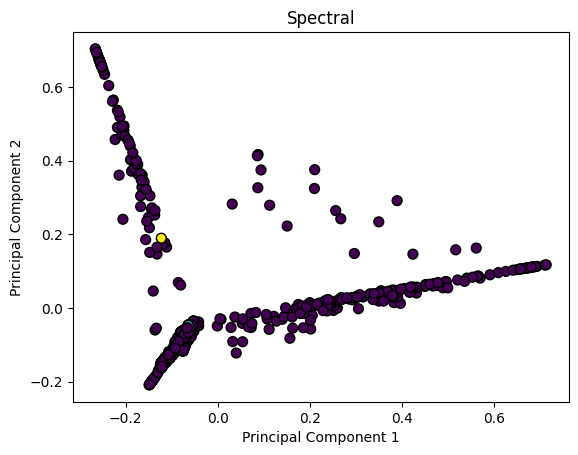

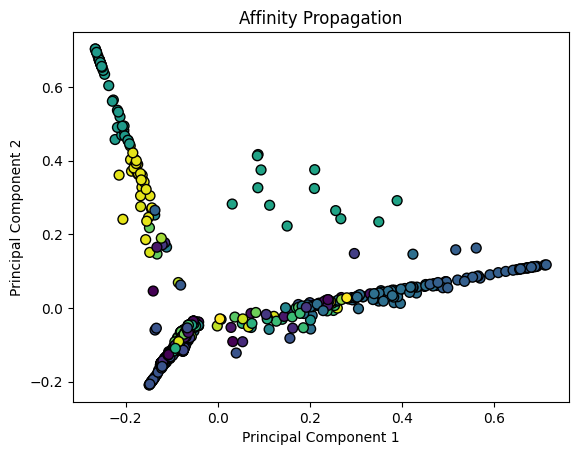

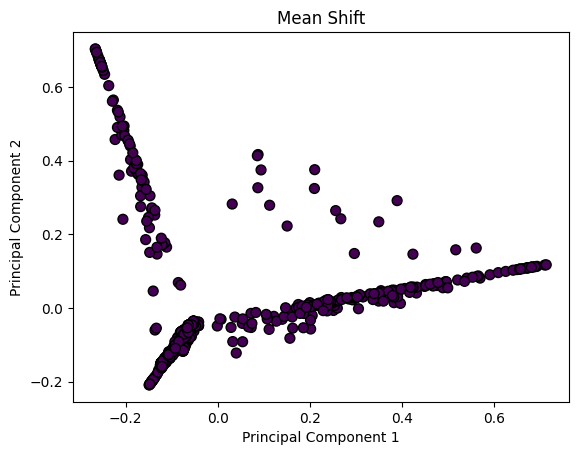

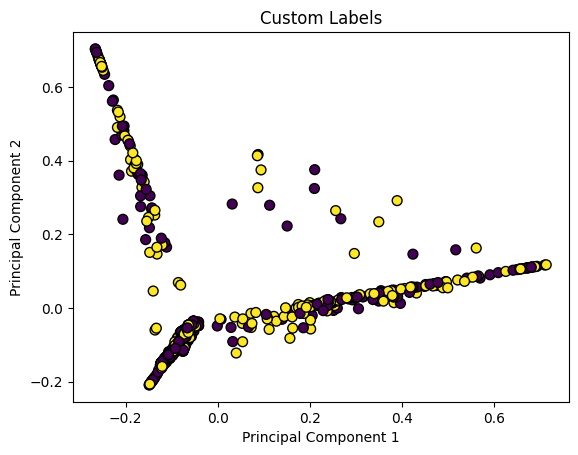

In [30]:
lda_embedding2 = reduce_dimension_with_lda(combined_e2["Sentences Overall"], tfidf_vectorizer, n_topics=50)
k_e2, h_e2, d2, g2, s2, a2, m2 = perform_clustering(lda_embedding2, combined_e2['Scene Type'].values)

/Users/alexanders/ml-project-2-peaceduke-1/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


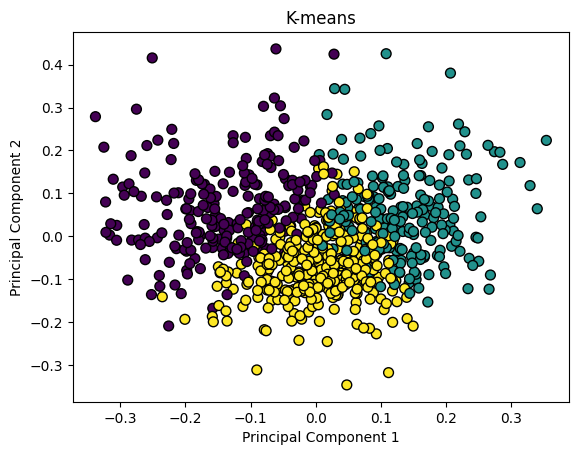

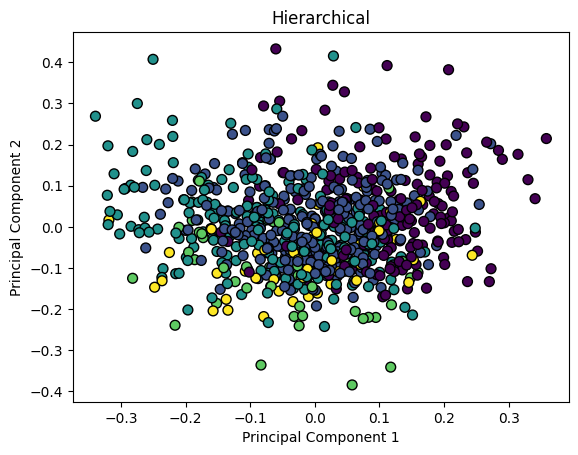

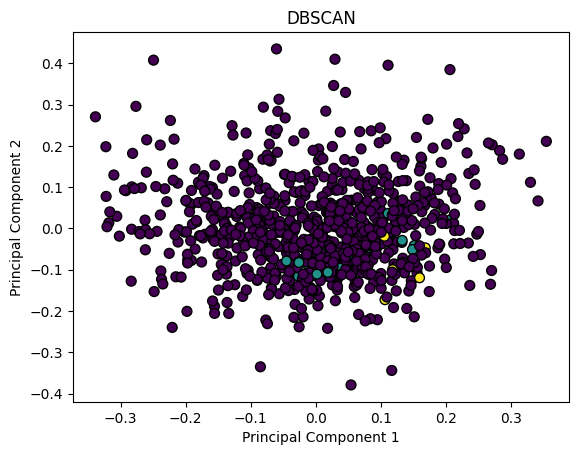

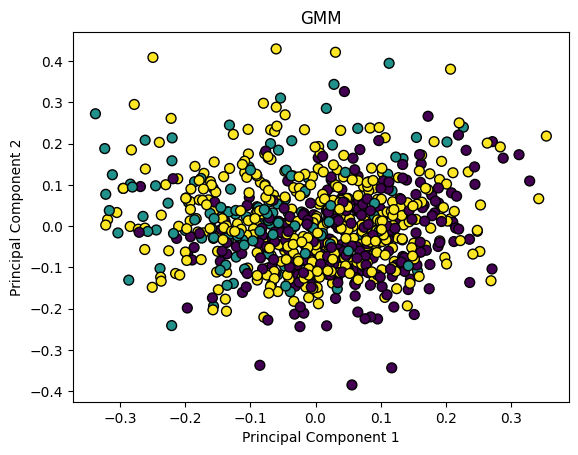

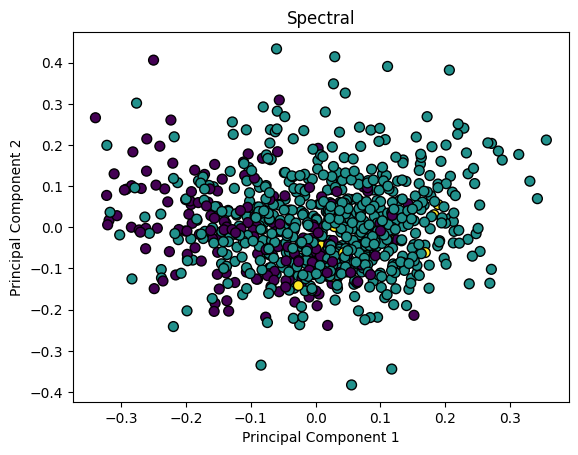

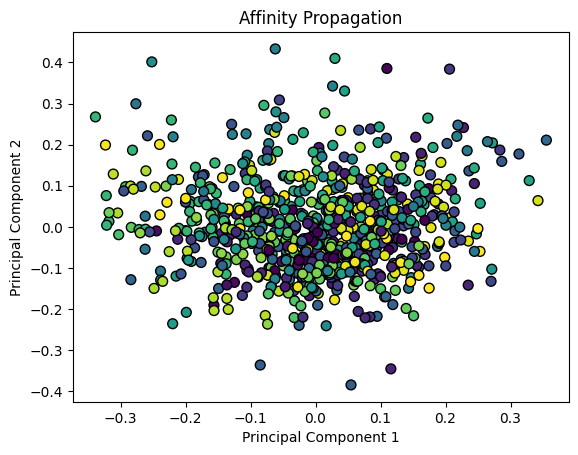

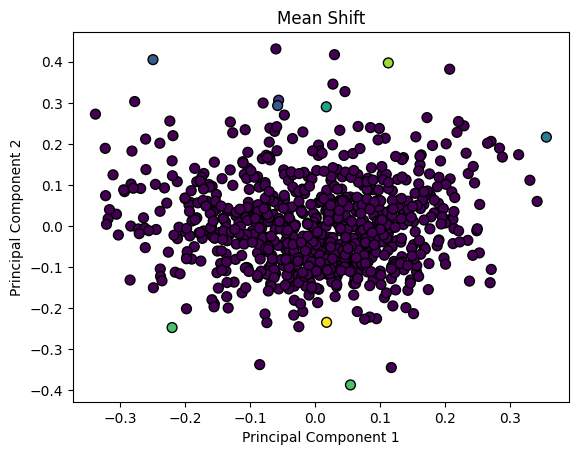

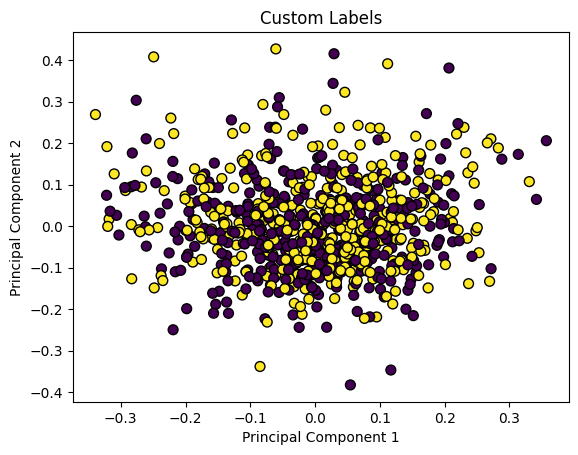

In [34]:
top_tfidf = get_top_n_tfidf_features(combined_e2["Sentences Overall"], tfidf_vectorizer, n=50)
k_e3, h_e3, d3, g3, s3, a3, m3 = perform_clustering(top_tfidf, combined_e2['Scene Type'].values)